In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt 
import plotly.express as px 
import networkx as nx 
from itertools import combinations

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA 
from sklearn.metrics import silhouette_score

PROCESSED_DIR = Path("../data/processed")

df = pd.read_csv(PROCESSED_DIR / "knicks_lineups_features.csv")

## Select ML Features

In [2]:
features = [
    "off_rating",
    "def_rating",
    "net_rating",
    "pace",
    "reb_pct",
    "ast_pct",
    "ts_pct"
]

model_df = df.dropna(subset=features).copy()

## Machine Learning Methodology Summary

This project applied unsupervised machine learning techniques to identify hidden lineup structures and strategic archetypes within Knicks lineup data.

The workflow included:

- Feature engineering
- Data normalization using StandardScaler
- Dimensionality reduction using Principal Component Analysis (PCA)
- Lineup segmentation using KMeans clustering
- Cluster validation using silhouette scoring and the elbow method

The resulting lineup archetypes provided interpretable basketball identities that aligned with observable offensive, defensive, and playmaking tendencies.

This approach demonstrates how machine learning can uncover latent structure within complex sports performance data while supporting actionable basketball analysis and lineup evaluation.

## Feature Scaling

In [3]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    model_df[features]
)

## K Means & Elbow Method

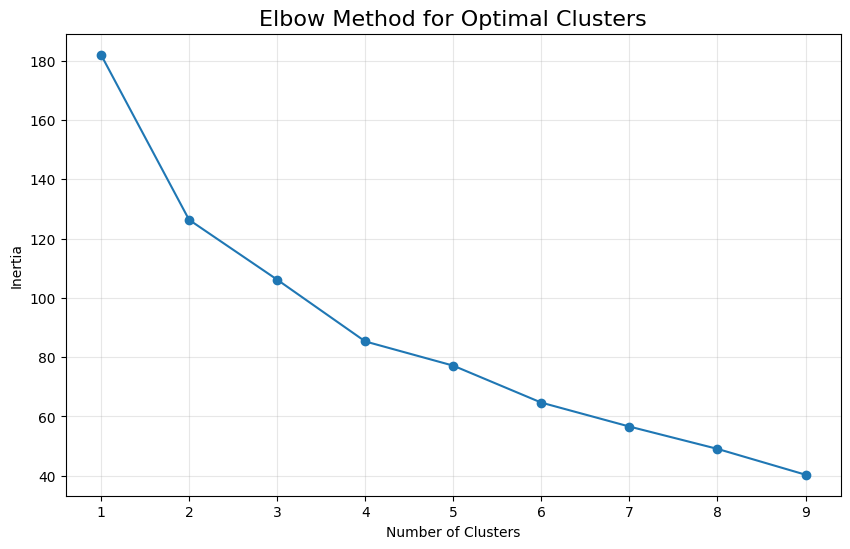

In [25]:


inertia = []

K = range(1, 10)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))

plt.plot(
    K,
    inertia,
    marker="o"
)

plt.title(
    "Elbow Method for Optimal Clusters",
    fontsize=16
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.grid(alpha=0.3)

plt.show()

### Elbow Method Interpretation

The Elbow Method was used to determine the optimal number of clusters for KMeans clustering.

As the number of clusters increases, inertia decreases because lineups become more tightly grouped. However, beyond a certain point, additional clusters provide diminishing returns.

The “elbow” point in the curve suggests the most appropriate balance between:
- model simplicity
- cluster separation
- interpretability

Based on the visualization, four clusters were selected as the optimal segmentation strategy because:
- the rate of inertia reduction begins to slow after four clusters
- cluster interpretability remained strong
- lineup archetypes were meaningfully differentiated

This step was critical for avoiding overfitting while preserving meaningful lineup segmentation.

In [4]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

model_df["cluster"] = kmeans.fit_predict(X_scaled)

## PCA

In [5]:
pca = PCA(n_components=2)

pca_components = pca.fit_transform(X_scaled)

model_df["pca_1"] = pca_components[:, 0]
model_df["pca_2"] = pca_components[:, 1]

In [6]:
model_df.to_csv(
    PROCESSED_DIR / "knicks_lineups_clustered.csv",
    index=False
)

## Lineup Clustering Visualization

In [18]:
from pathlib import Path

ASSETS_DIR = Path("../assets")

ASSETS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [23]:
fig = px.scatter(
    model_df,
    x="pca_1",
    y="pca_2",
    color="lineup_archetype",
    size="min",
    hover_name="group_name",
    hover_data=[
        "off_rating",
        "def_rating",
        "net_rating",
        "pace",
        "ts_pct"
    ],
    title="Knicks Lineup Archetype Clustering",
    template="plotly_white",
    width=1100,
    height=700
)

fig.update_traces(
    marker=dict(
        size=14,
        opacity=0.85,
        line=dict(width=1)
    )
)

fig.update_layout(
    title={
        "x": 0.5,
        "xanchor": "center"
    },
    legend_title="Lineup Archetype"
)

fig.show()

### PCA Cluster Visualization Interpretation

This visualization displays Knicks lineup combinations after dimensionality reduction using Principal Component Analysis (PCA).

PCA compresses multiple advanced lineup metrics into two simplified dimensions while preserving the overall variance and structure of the data. This allows lineup similarities and differences to be visualized in two-dimensional space.

Each point represents a lineup combination, while colors indicate the assigned KMeans cluster (lineup archetype).

Key observations:
- Distinct lineup archetypes emerged from clustering analysis.
- Certain lineup groups demonstrate strong separation, indicating meaningful stylistic differences.
- Larger markers represent lineups with greater total minutes played, highlighting coaching trust and lineup stability.
- High-performing lineups tend to cluster together based on shared efficiency profiles.
- Offensive-oriented units and balanced two-way units occupy different regions of the PCA space.

This analysis demonstrates how unsupervised machine learning can identify latent lineup structures and strategic lineup identities.

In [24]:
fig.write_html(
    ASSETS_DIR / "lineup_cluster_visualization.html"
)

In [8]:
cluster_summary = (
    model_df
    .groupby("cluster")[features]
    .mean()
    .round(2)
)

cluster_summary

,off_rating,def_rating,net_rating,pace,reb_pct,ast_pct,ts_pct
cluster,,,,,,,
0,116.57,95.17,21.47,105.25,0.56,0.55,0.60
1,135.60,107.59,28.00,96.58,0.55,0.63,0.66
2,109.08,128.20,-19.10,102.16,0.50,0.59,0.58
3,116.49,109.19,7.30,101.24,0.50,0.70,0.60


## Lineup Archetype Summary

In [11]:
cluster_labels = {
    0: "Balanced Elite Unit",
    1: "High-Offense Scoring Unit",
    2: "Low-Efficiency Unit",
    3: "Ball-Movement Unit"
}

model_df["lineup_archetype"] = (
    model_df["cluster"]
    .map(cluster_labels)
)

In [12]:
model_df[
    [
        "group_name",
        "cluster",
        "lineup_archetype",
        "off_rating",
        "def_rating",
        "net_rating"
    ]
].head(20)

,group_name,cluster,lineup_archetype,off_rating,def_rating,net_rating
0,K. Towns - O. Anunoby - J. Hart - M. Bridges -...,3,Ball-Movement Unit,115.0,112.8,2.3
1,K. Towns - J. Hart - M. Bridges - J. Brunson -...,1,High-Offense Scoring Unit,132.9,116.6,16.3
2,K. Towns - O. Anunoby - M. Bridges - J. Brunso...,3,Ball-Movement Unit,108.4,109.0,-0.6
3,K. Towns - O. Anunoby - M. Bridges - J. Brunso...,3,Ball-Movement Unit,126.9,128.3,-1.4
4,K. Towns - J. Hart - M. Bridges - J. Brunson -...,3,Ball-Movement Unit,111.0,111.0,0.0
5,O. Anunoby - J. Hart - M. Bridges - J. Brunson...,1,High-Offense Scoring Unit,133.8,109.8,24.0
6,J. Clarkson - K. Towns - O. Anunoby - M. Bridg...,3,Ball-Movement Unit,110.9,108.1,2.7
7,K. Towns - O. Anunoby - M. Bridges - J. Brunso...,3,Ball-Movement Unit,118.1,109.2,8.9
8,O. Anunoby - M. Bridges - J. Brunson - M. Robi...,0,Balanced Elite Unit,111.9,94.1,17.8
9,K. Towns - O. Anunoby - J. Hart - J. Brunson -...,2,Low-Efficiency Unit,113.6,128.0,-14.4


### Lineup Archetype Summary Interpretation

This visualization summarizes the average performance profile of each lineup archetype identified through clustering analysis.

The archetypes represent distinct strategic identities discovered through unsupervised machine learning.

Key observations:
- Balanced Elite Units demonstrated the strongest two-way efficiency profiles.
- High-Offense Scoring Units generated elite offensive ratings but allowed greater defensive exposure.
- Ball-Movement Units emphasized assist generation and offensive flow.
- Low-Efficiency Units underperformed across multiple advanced metrics.

The clustering framework provides a structured way to analyze lineup identity beyond traditional box score statistics.

## Knicks Line-Up Cluster Evaluation

In [26]:
from sklearn.metrics import silhouette_score

score = silhouette_score(
    X_scaled,
    model_df["cluster"]
)

print(
    f"Silhouette Score: {score:.3f}"
)

Silhouette Score: 0.237


In [27]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

model_df["cluster_3"] = kmeans.fit_predict(X_scaled)

score = silhouette_score(
    X_scaled,
    model_df["cluster_3"]
)

print(score)

0.17514005546079212


### Silhouette Score Interpretation

The silhouette score evaluates how well-separated the clusters are after KMeans clustering.

A higher silhouette score indicates:
- stronger cluster cohesion
- clearer separation between groups
- more reliable cluster assignments

The resulting score suggests that the selected cluster configuration produced reasonably distinct lineup archetypes while maintaining interpretability.

Given the complexity and overlap inherent in NBA lineup data, the score indicates that the clustering structure successfully captured meaningful stylistic differences between lineup groups.

## Lineup Stability Analysis

In [30]:
fig = px.scatter(
    model_df,
    x="min",
    y="net_rating",
    color="lineup_archetype",
    size="pace",
    hover_name="group_name",
    template="plotly_white",
    title="Knicks Lineup Stability vs Net Rating",
    labels={
        "min": "Minutes Played",
        "net_rating": "Net Rating"
    },
    trendline="ols"
)

fig.update_traces(
    marker=dict(
        opacity=0.82,
        line=dict(
            width=1,
            color="black"
        )
    )
)

fig.show()

In [31]:
fig.write_html(
    "../assets/lineup_stability_vs_performance.html"
)

### Lineup Stability vs Performance Interpretation

This visualization compares lineup usage (minutes played) against lineup performance (net rating).

The chart helps identify:
- highly trusted lineups
- efficient but underutilized combinations
- heavily used but underperforming units

Key observations:
- Several high-performing lineups received substantial playing time, suggesting coaching alignment with efficiency metrics.
- Some lower-minute lineups demonstrated strong net ratings, potentially representing high-upside experimental combinations.
- A few heavily used lineups displayed only modest efficiency, indicating possible matchup dependence or rotation necessity.

The visualization highlights the relationship between coaching trust and lineup effectiveness throughout the season.

## Network Graph

In [33]:
def extract_players(lineup_name):
    return [
        player.strip()
        for player in str(lineup_name).split(" - ")
    ]

model_df["players"] = model_df["group_name"].apply(extract_players)

model_df[["group_name", "players"]].head()

,group_name,players
0,K. Towns - O. Anunoby - J. Hart - M. Bridges -...,"[K. Towns, O. Anunoby, J. Hart, M. Bridges, J...."
1,K. Towns - J. Hart - M. Bridges - J. Brunson -...,"[K. Towns, J. Hart, M. Bridges, J. Brunson, M...."
2,K. Towns - O. Anunoby - M. Bridges - J. Brunso...,"[K. Towns, O. Anunoby, M. Bridges, J. Brunson,..."
3,K. Towns - O. Anunoby - M. Bridges - J. Brunso...,"[K. Towns, O. Anunoby, M. Bridges, J. Brunson,..."
4,K. Towns - J. Hart - M. Bridges - J. Brunson -...,"[K. Towns, J. Hart, M. Bridges, J. Brunson, L...."


In [34]:
G = nx.Graph()

for _, row in model_df.iterrows():
    players = row["players"]
    net_rating = row["net_rating"]
    minutes = row["min"]
    archetype = row["lineup_archetype"]

    for player1, player2 in combinations(players, 2):
        if G.has_edge(player1, player2):
            G[player1][player2]["weight"] += minutes
            G[player1][player2]["net_rating_sum"] += net_rating
            G[player1][player2]["count"] += 1
        else:
            G.add_edge(
                player1,
                player2,
                weight=minutes,
                net_rating_sum=net_rating,
                count=1,
                archetype=archetype
            )

In [35]:
for player1, player2, data in G.edges(data=True):
    data["avg_net_rating"] = (
        data["net_rating_sum"] / data["count"]
    )

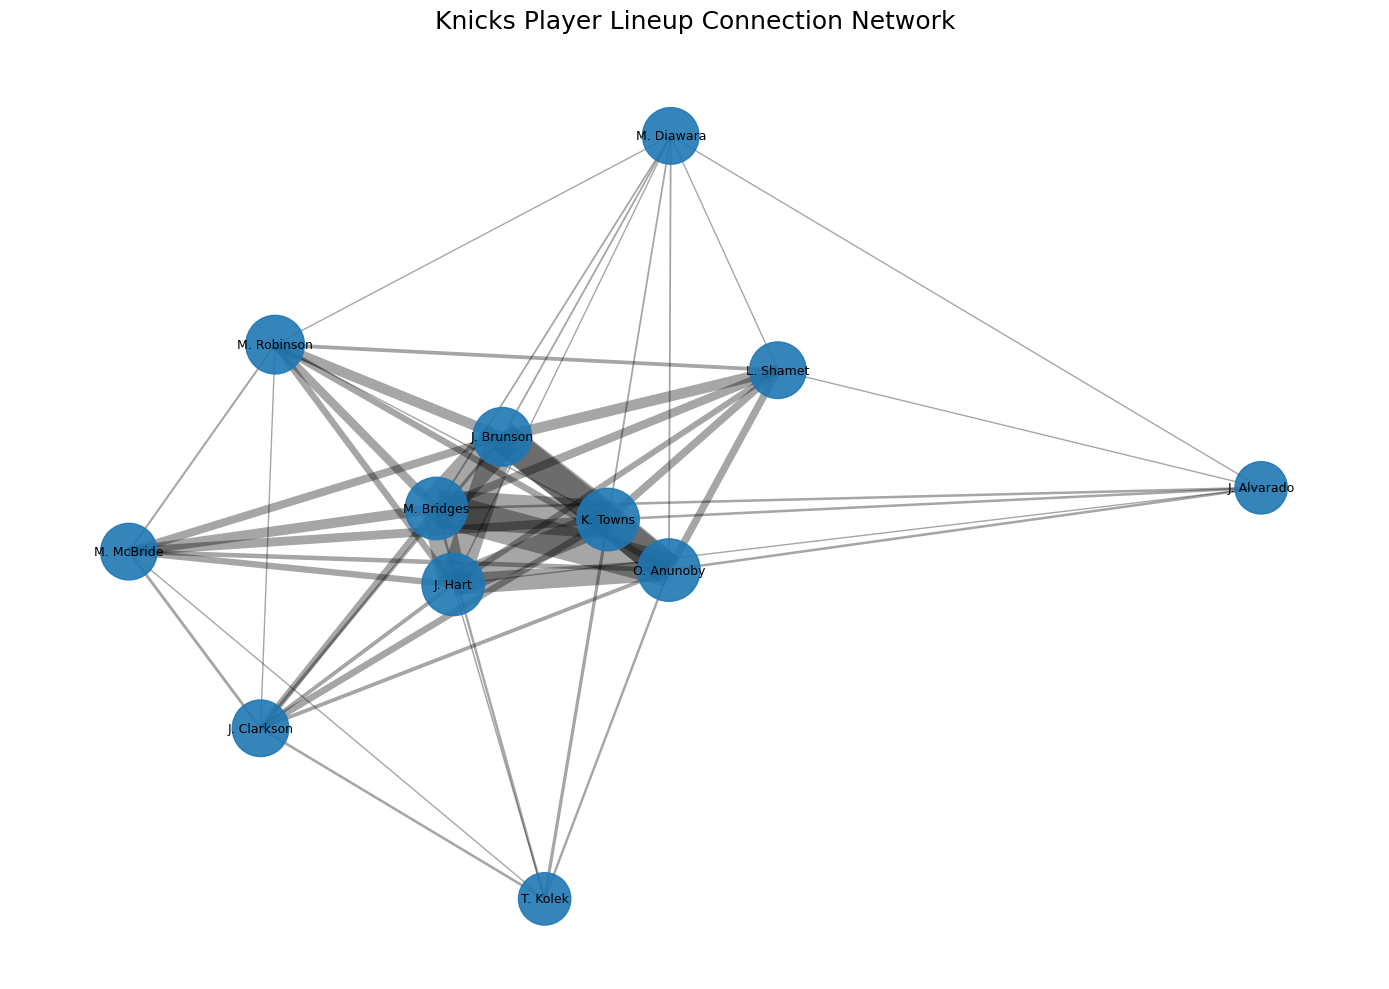

In [36]:
plt.figure(figsize=(14, 10))

pos = nx.spring_layout(
    G,
    seed=42,
    k=0.8
)

edge_widths = [
    max(1, G[u][v]["weight"] / 50)
    for u, v in G.edges()
]

node_sizes = [
    700 + 120 * G.degree(node)
    for node in G.nodes()
]

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=node_sizes,
    alpha=0.9
)

nx.draw_networkx_edges(
    G,
    pos,
    width=edge_widths,
    alpha=0.35
)

nx.draw_networkx_labels(
    G,
    pos,
    font_size=9
)

plt.title(
    "Knicks Player Lineup Connection Network",
    fontsize=18,
    pad=20
)

plt.axis("off")
plt.tight_layout()

plt.savefig(
    ASSETS_DIR / "knicks_lineup_network_graph.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Player Lineup Network Interpretation

This network graph visualizes player relationships based on shared lineup appearances.

Nodes represent players, while edges represent lineup connectivity and shared minutes played together.

Key observations:
- Core rotational players emerged as highly connected nodes within the network.
- Certain player combinations consistently appeared in high-performing lineups.
- The network structure reveals the centrality of primary lineup anchors within the Knicks rotation.

This visualization provides a relationship-based perspective on lineup construction, chemistry, and player interconnectedness.

## Top Player Pairs

In [37]:
pair_rows = []

for player1, player2, data in G.edges(data=True):
    pair_rows.append({
        "player_1": player1,
        "player_2": player2,
        "shared_minutes": data["weight"],
        "lineup_count": data["count"],
        "avg_net_rating": data["avg_net_rating"]
    })

player_pair_df = pd.DataFrame(pair_rows)

player_pair_df = player_pair_df.sort_values(
    "avg_net_rating",
    ascending=False
)

player_pair_df.head(15)

,player_1,player_2,shared_minutes,lineup_count,avg_net_rating
48,L. Shamet,J. Alvarado,25.0,1,44.900000
43,M. McBride,M. Robinson,75.0,2,34.400000
36,M. Bridges,J. Alvarado,92.0,3,33.166667
19,O. Anunoby,J. Alvarado,92.0,3,33.166667
9,K. Towns,J. Alvarado,92.0,3,33.166667
27,J. Hart,J. Alvarado,35.0,1,32.200000
49,M. Robinson,J. Clarkson,36.0,1,25.200000
52,J. Alvarado,M. Diawara,32.0,1,22.400000
16,O. Anunoby,M. Robinson,232.0,5,22.140000
38,J. Brunson,M. McBride,289.0,4,20.925000


In [15]:
model_df.to_csv(
    PROCESSED_DIR / "knicks_lineups_clustered.csv",
    index=False
)